<a href="https://colab.research.google.com/github/kej534923-maker/ECON5200-Applied-Data-Analytics/blob/main/lab_ch24_diagnostic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 24: Causal ML — Double Machine Learning (Diagnostic Lab)
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | 40 min Core + 20 min Extension

---

**Format:** This lab contains **deliberately flawed code**. Your job:
1. Run the code
2. Identify what is wrong (you are told how many bugs, not where)
3. Fix the issue
4. Verify on a known DGP
5. Extend with Causal Forests

**Learning Objectives:**
- Implement manual 2-fold cross-fitting from scratch and debug common mistakes
- Understand why cross-fitting, treatment residualization, and the IV-style formula are each essential
- Estimate the ATE of 401(k) eligibility using the DoubleML package
- Assess robustness with sensitivity analysis
- Fit a Causal Forest (EconML) to estimate individual-level CATEs
- Compare subgroup DML to Causal Forest heterogeneity detection

**Verification checkpoints** are provided so you can confirm you found the right errors.

**Time estimate:** ~60 minutes

---

In [6]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages and import libraries
# -----------------------------------------------------------
!pip install -q doubleml econml

from doubleml import DoubleMLData, DoubleMLPLR
from doubleml.datasets import fetch_401K
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LassoCV
from sklearn.model_selection import KFold
from econml.dml import CausalForestDML
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Load 401(k) data
data = fetch_401K(return_type='DataFrame')

print(f'Dataset shape: {data.shape}')
print(f'Columns: {list(data.columns)}')
print('Libraries loaded. Ready to diagnose.')

Dataset shape: (9915, 14)
Columns: ['nifa', 'net_tfa', 'tw', 'age', 'inc', 'fsize', 'educ', 'db', 'marr', 'twoearn', 'e401', 'p401', 'pira', 'hown']
Libraries loaded. Ready to diagnose.


---

## Part A: Manual Cross-Fitting — DIAGNOSE

The code below attempts to implement the DML algorithm manually using
2-fold cross-fitting. It has **three deliberate bugs**:

1. **Bug 1 (Data Leakage):** Uses the same data for training AND residual computation — violates cross-fitting
2. **Bug 2 (Missing Residualization):** Only residualizes the outcome $Y$, not the treatment $D$
3. **Bug 3 (Wrong Formula):** Uses `np.mean` of residual products instead of the correct IV-style formula for $\hat{\theta}$

**Your task:** Find all three bugs, explain why each matters, and fix them.

**The correct DML formula:**

$$\hat{\theta} = \frac{\sum_i \tilde{D}_i \tilde{Y}_i}{\sum_i \tilde{D}_i D_i}$$

where $\tilde{Y}_i = Y_i - \hat{\ell}(X_i)$ and $\tilde{D}_i = D_i - \hat{m}(X_i)$ are
the residuals from cross-fitted nuisance models.

In [ ]:
# -----------------------------------------------------------
# DIAGNOSE: This code has 3 bugs. Find and fix them all.
# Manual 2-fold cross-fitting DML
# -----------------------------------------------------------

# Generate simulated data with known ATE for verification
np.random.seed(42)
n = 5000
p = 100
TRUE_ATE = 5.0

X_sim = np.random.normal(0, 1, size=(n, p))
propensity = 1 / (1 + np.exp(-(0.5 * X_sim[:, 0] + 0.3 * X_sim[:, 1] + 0.2 * X_sim[:, 2])))
D_sim = np.random.binomial(1, propensity)
Y_sim = (TRUE_ATE * D_sim
         + 2.0 * X_sim[:, 0] + 1.5 * X_sim[:, 1] + 1.0 * X_sim[:, 2]
         + 0.5 * X_sim[:, 3] + 0.3 * X_sim[:, 4]
         + np.random.normal(0, 1, n))


def broken_dml(Y, D, X, random_state=42):
    """
    BROKEN manual DML implementation with 3 bugs.

    Bug 1: Uses same fold for training and prediction (no cross-fitting)
    Bug 2: Only residualizes Y, not D
    Bug 3: Uses np.mean(V_tilde * Y_tilde) instead of sum(V_tilde * Y_tilde) / sum(V_tilde * D)
    """
    n = len(Y)
    kf = KFold(n_splits=2, shuffle=True, random_state=random_state)

    Y_tilde = np.zeros(n)  # outcome residuals
    V_tilde = np.zeros(n)  # treatment residuals (but Bug 2 skips this)

    for train_idx, test_idx in kf.split(X):
        # --- Outcome model: Y ~ X ---
        ml_l = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)

        # BUG 1: Training and predicting on the SAME fold (train_idx)
        # Should train on train_idx, predict on test_idx
        ml_l.fit(X[train_idx], Y[train_idx])
        Y_hat = ml_l.predict(X[train_idx])       # <-- BUG: should be X[test_idx]
        Y_tilde[train_idx] = Y[train_idx] - Y_hat  # <-- BUG: should index test_idx

        # BUG 2: Missing treatment residualization entirely
        # Should fit ml_m on D ~ X and compute D_tilde = D - D_hat
        # Instead, just uses raw D as V_tilde
        V_tilde[train_idx] = D[train_idx]  # <-- BUG: should be D[test_idx] - D_hat[test_idx]

    # BUG 3: Wrong formula — uses np.mean instead of IV-style ratio
    # Correct: theta = sum(V_tilde * Y_tilde) / sum(V_tilde * D)
    theta = np.mean(V_tilde * Y_tilde)  # <-- BUG: wrong formula

    return theta


# Run the broken version
broken_ate = broken_dml(Y_sim, D_sim, X_sim)

print('=== BROKEN DML Results ===')
print(f'True ATE:    {TRUE_ATE:.2f}')
print(f'Broken ATE:  {broken_ate:.2f}')
print(f'Bias:        {broken_ate - TRUE_ATE:+.2f}')
print()
print('This estimate is far from the true ATE of 5.0.')
print('Find and fix the 3 bugs to recover the correct estimate.')

Bug 1: Data Leakage (No Cross-Fitting)
Issue:
The nuisance model for Y is trained and evaluated on the same fold (train_idx). This violates the cross-fitting requirement.

Why it matters:
DML relies on out-of-fold predictions to avoid overfitting bias in residuals. Using the same data for training and prediction leads to overly optimistic estimates of
ℓ
^
(X), which contaminates the residuals and biases the ATE estimate.

Bug 2: Missing Treatment Residualization

Issue:
The broken code does not residualize the treatment D. Instead, it directly uses raw D.

Why it matters:
DML requires removing the effect of covariates X from both outcome and treatment:

D
~
i
	​

=D
i
	​

−
m
^
(X
i
	​

)

Without this step, confounding from X remains, and the estimator is no longer orthogonal, leading to biased causal estimates.

Bug 3: Incorrect Estimator Formula

Issue:
The broken code uses:

mean(
D
~
i
	​

Y
~
i
	​

)

which is not the correct DML estimator.

Why it matters:
DML uses an IV-style ratio estimator, not a simple average. The correct formula ensures orthogonality and consistency.

In [2]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# -----------------------------------------------------------
# Generate simulated data with known ATE for verification
# -----------------------------------------------------------
np.random.seed(42)
n = 5000
p = 100
TRUE_ATE = 5.0

X_sim = np.random.normal(0, 1, size=(n, p))
propensity = 1 / (1 + np.exp(-(0.5 * X_sim[:, 0] + 0.3 * X_sim[:, 1] + 0.2 * X_sim[:, 2])))
D_sim = np.random.binomial(1, propensity)
Y_sim = (TRUE_ATE * D_sim
         + 2.0 * X_sim[:, 0] + 1.5 * X_sim[:, 1] + 1.0 * X_sim[:, 2]
         + 0.5 * X_sim[:, 3] + 0.3 * X_sim[:, 4]
         + np.random.normal(0, 1, n))

# -----------------------------------------------------------
# BROKEN version from the prompt
# -----------------------------------------------------------
def broken_dml(Y, D, X, random_state=42):
    """
    BROKEN manual DML implementation with 3 bugs.

    Bug 1: Uses same fold for training and prediction (no cross-fitting)
    Bug 2: Only residualizes Y, not D
    Bug 3: Uses np.mean(V_tilde * Y_tilde) instead of sum(V_tilde * Y_tilde) / sum(V_tilde * D)
    """
    n = len(Y)
    kf = KFold(n_splits=2, shuffle=True, random_state=random_state)

    Y_tilde = np.zeros(n)
    V_tilde = np.zeros(n)

    for train_idx, test_idx in kf.split(X):
        ml_l = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)

        # BUG 1
        ml_l.fit(X[train_idx], Y[train_idx])
        Y_hat = ml_l.predict(X[train_idx])
        Y_tilde[train_idx] = Y[train_idx] - Y_hat

        # BUG 2
        V_tilde[train_idx] = D[train_idx]

    # BUG 3
    theta = np.mean(V_tilde * Y_tilde)

    return theta

# -----------------------------------------------------------
# FIXED version
# -----------------------------------------------------------
def fixed_dml(Y, D, X, random_state=42):
    """
    FIXED manual DML implementation.

    Fix 1: Cross-fit — train on one fold, predict on the other
    Fix 2: Residualize BOTH Y and D
    Fix 3: Use the IV-style formula:
           theta = sum(V_tilde * Y_tilde) / sum(V_tilde * D)
    """
    n = len(Y)
    kf = KFold(n_splits=2, shuffle=True, random_state=random_state)

    Y_tilde = np.zeros(n)   # residualized outcome
    V_tilde = np.zeros(n)   # residualized treatment

    for train_idx, test_idx in kf.split(X):
        # Outcome model: l(X) = E[Y|X]
        ml_l = RandomForestRegressor(
            n_estimators=200,
            max_depth=5,
            random_state=42
        )
        ml_l.fit(X[train_idx], Y[train_idx])
        Y_hat = ml_l.predict(X[test_idx])   # cross-fitted prediction
        Y_tilde[test_idx] = Y[test_idx] - Y_hat

        # Treatment model: m(X) = E[D|X]
        # Since D is binary, classifier is appropriate
        ml_m = RandomForestClassifier(
            n_estimators=200,
            max_depth=5,
            random_state=42
        )
        ml_m.fit(X[train_idx], D[train_idx])
        D_hat = ml_m.predict_proba(X[test_idx])[:, 1]   # estimated propensity
        V_tilde[test_idx] = D[test_idx] - D_hat

    # IV-style DML estimator
    theta = np.sum(V_tilde * Y_tilde) / np.sum(V_tilde * D)

    return theta

# -----------------------------------------------------------
# Run both versions
# -----------------------------------------------------------
broken_ate = broken_dml(Y_sim, D_sim, X_sim)
fixed_ate = fixed_dml(Y_sim, D_sim, X_sim)

print('=== BROKEN DML Results ===')
print(f'True ATE:    {TRUE_ATE:.2f}')
print(f'Broken ATE:  {broken_ate:.2f}')
print(f'Bias:        {broken_ate - TRUE_ATE:+.2f}')
print()

print('=== FIXED DML Results ===')
print(f'True ATE:    {TRUE_ATE:.2f}')
print(f'Fixed ATE:   {fixed_ate:.2f}')
print(f'Bias:        {fixed_ate - TRUE_ATE:+.2f}')
print()

# -----------------------------------------------------------
# VERIFICATION CHECKPOINT
# -----------------------------------------------------------
if abs(fixed_ate - TRUE_ATE) < 1.0:
    print('PASS — Fixed ATE is within 1.0 of the true value.')
else:
    print('FAIL — Fixed ATE is still far from 5.0. Check your fixes.')

=== BROKEN DML Results ===
True ATE:    5.00
Broken ATE:  1.09
Bias:        -3.91

=== FIXED DML Results ===
True ATE:    5.00
Fixed ATE:   5.00
Bias:        +0.00

PASS — Fixed ATE is within 1.0 of the true value.


---

## Part B: Package-Based DML

Now use the `doubleml` package to estimate the 401(k) ATE properly.
Less scaffolding than the 3916 lab — you should know the API from Part A.

In [9]:
pip install doubleml econml scikit-learn pandas matplotlib

In [11]:
# -----------------------------------------------------------
# Part B: Package-Based DML
# 401(k) ATE with DoubleML
# -----------------------------------------------------------

# If needed:
# !pip install doubleml scikit-learn pandas matplotlib

import numpy as np
import pandas as pd
import doubleml as dml
from doubleml import DoubleMLPLR
from doubleml.datasets import fetch_401K
from sklearn.ensemble import RandomForestRegressor

# -----------------------------------------------------------
# 1. Load the built-in 401(k) dataset from DoubleML
#    return_type='DataFrame' gives a pandas DataFrame
# -----------------------------------------------------------
df = fetch_401K(return_type='DataFrame')

print("Data shape:", df.shape)
print("First 10 columns:", df.columns[:10].tolist())
print("Contains net_tfa?", 'net_tfa' in df.columns)
print("Contains e401?", 'e401' in df.columns)

# -----------------------------------------------------------
# 2. Define outcome, treatment, controls
#    y_col = 'net_tfa'
#    d_col = 'e401'
#    x_cols = everything else
# -----------------------------------------------------------
y_col = 'net_tfa'
d_col = 'e401'
x_cols = [col for col in df.columns if col not in [y_col, d_col]]

print("Outcome:", y_col)
print("Treatment:", d_col)
print("Number of controls:", len(x_cols))

# -----------------------------------------------------------
# 3. Create DoubleMLData
# -----------------------------------------------------------
dml_data = dml.DoubleMLData(
    df,
    y_col=y_col,
    d_cols=d_col,
    x_cols=x_cols
)

# -----------------------------------------------------------
# 4. Define nuisance learners
#    Assignment asks for RandomForestRegressor for both ml_l and ml_m
# -----------------------------------------------------------
ml_l = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

ml_m = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

# -----------------------------------------------------------
# 5. Fit PLR with 5 folds
# -----------------------------------------------------------
dml_plr = DoubleMLPLR(
    obj_dml_data=dml_data,
    ml_l=ml_l,
    ml_m=ml_m,
    n_folds=5
)

dml_plr.fit()

# -----------------------------------------------------------
# 6. Main results
# -----------------------------------------------------------
print("=== DoubleML PLR Summary ===")
print(dml_plr.summary)
print()

ate = dml_plr.coef[0]
ci = dml_plr.confint()

print(f"ATE: ${ate:,.0f}")
print(f"95% CI: [{ci.iloc[0,0]:,.0f}, {ci.iloc[0,1]:,.0f}]")
print()

# -----------------------------------------------------------
# 7. Sensitivity analysis
# -----------------------------------------------------------
dml_plr.sensitivity_analysis(cf_y=0.03, cf_d=0.03)

print("=== Sensitivity Summary ===")
print(dml_plr.sensitivity_summary)
print()

# -----------------------------------------------------------
# 8. Optional: extract robustness value if available
# -----------------------------------------------------------
try:
    print("Sensitivity params:")
    print(dml_plr.sensitivity_params)
except Exception as e:
    print("Could not print sensitivity_params:", e)

Data shape: (9915, 14)
First 10 columns: ['nifa', 'net_tfa', 'tw', 'age', 'inc', 'fsize', 'educ', 'db', 'marr', 'twoearn']
Contains net_tfa? True
Contains e401? True
Outcome: net_tfa
Treatment: e401
Number of controls: 12
=== DoubleML PLR Summary ===
            coef     std err         t     P>|t|        2.5 %      97.5 %
e401 -835.379605  482.772946 -1.730378  0.083563 -1781.597193  110.837982

ATE: $-835
95% CI: [-1,782, 111]

=== Sensitivity Summary ===
================== Sensitivity Analysis ==================

------------------ Scenario          ------------------
Significance Level: level=0.95
Sensitivity parameters: cf_y=0.03; cf_d=0.03, rho=1.0

------------------ Bounds with CI    ------------------
         CI lower  theta lower       theta  theta upper     CI upper
e401 -3530.865787 -2699.249862 -835.379605  1028.490652  1809.245934

------------------ Robustness Values ------------------
      H_0   RV (%)   RVa (%)
e401  0.0  1.35606  0.068414

Sensitivity params:
{'thet

In [12]:
# -----------------------------------------------------------
# Sensitivity Analysis
# -----------------------------------------------------------

# Run sensitivity analysis
dml_plr.sensitivity_analysis(cf_y=0.03, cf_d=0.03)

# Print summary
print("=== Sensitivity Summary ===")
print(dml_plr.sensitivity_summary)
print()

# Try to extract robustness value (depends on version)
try:
    robustness_value = dml_plr.sensitivity_params['robustness_value']
    print(f"Robustness Value: {robustness_value:.3f}")
except:
    print("Robustness value not directly available. Check summary above.")

=== Sensitivity Summary ===
================== Sensitivity Analysis ==================

------------------ Scenario          ------------------
Significance Level: level=0.95
Sensitivity parameters: cf_y=0.03; cf_d=0.03, rho=1.0

------------------ Bounds with CI    ------------------
         CI lower  theta lower       theta  theta upper     CI upper
e401 -3530.865787 -2699.249862 -835.379605  1028.490652  1809.245934

------------------ Robustness Values ------------------
      H_0   RV (%)   RVa (%)
e401  0.0  1.35606  0.068414

Robustness value not directly available. Check summary above.


---

## Part C: Causal Forests (EXTEND)

DML estimates a single ATE (or subgroup ATEs if you manually split).
**Causal Forests** from the `econml` package estimate individual-level
Conditional Average Treatment Effects (CATEs) — a treatment effect
for every observation.

The `CausalForestDML` combines:
- DML-style cross-fitting for debiasing
- Random Forest splitting to discover heterogeneity
- Honesty: separate samples for splitting and estimation

In [13]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Set up CausalForestDML from EconML
# -----------------------------------------------------------

# Prepare data arrays
y_col = 'net_tfa'
d_col = 'e401'
x_cols = [c for c in data.columns if c not in [y_col, d_col]]

Y = data[y_col].values
D = data[d_col].values.reshape(-1, 1)
X = data[x_cols].values

print(f'Y shape: {Y.shape}')
print(f'D shape: {D.shape}')
print(f'X shape: {X.shape}')
print(f'Covariates: {x_cols}')
print()

# Initialize CausalForestDML
cf = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
    model_t=RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
    n_estimators=500,   # Number of causal trees
    min_samples_leaf=20,
    max_depth=10,
    random_state=42,
    cv=5                # Cross-fitting folds
)

print('CausalForestDML configured.')
print('Next: fit the model and extract individual CATEs.')

Y shape: (9915,)
D shape: (9915, 1)
X shape: (9915, 12)
Covariates: ['nifa', 'tw', 'age', 'inc', 'fsize', 'educ', 'db', 'marr', 'twoearn', 'p401', 'pira', 'hown']

CausalForestDML configured.
Next: fit the model and extract individual CATEs.


In [14]:
# -----------------------------------------------------------
# Part C: Causal Forests (EXTEND)
# Fit CausalForestDML and extract CATE predictions
# -----------------------------------------------------------

import numpy as np
from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor

# -----------------------------------------------------------
# 1. Define outcome, treatment, controls
#    Assumes df already exists from Part B
# -----------------------------------------------------------
y_col = 'net_tfa'
d_col = 'e401'
x_cols = [col for col in df.columns if col not in [y_col, d_col]]

Y = df[y_col].to_numpy()
D = df[d_col].to_numpy()
X = df[x_cols].to_numpy()

print("Y shape:", Y.shape)
print("D shape:", D.shape)
print("X shape:", X.shape)

# -----------------------------------------------------------
# 2. Fit the Causal Forest
#    This may take 1-3 minutes
# -----------------------------------------------------------
cf = CausalForestDML(
    model_y=RandomForestRegressor(
        n_estimators=200,
        max_depth=5,
        random_state=42
    ),
    model_t=RandomForestRegressor(
        n_estimators=200,
        max_depth=5,
        random_state=42
    ),
    n_estimators=500,
    min_samples_leaf=10,
    max_depth=10,
    random_state=42,
    discrete_treatment=True,
    cv=5
)

cf.fit(Y, D, X=X)

# -----------------------------------------------------------
# 3. Extract individual CATE predictions
# -----------------------------------------------------------
cate_predictions = cf.effect(X)

# -----------------------------------------------------------
# 4. Get 95% confidence intervals
# -----------------------------------------------------------
cate_lower, cate_upper = cf.effect_interval(X, alpha=0.05)

# -----------------------------------------------------------
# 5. Verification output
# -----------------------------------------------------------
print("=== Causal Forest Results ===")
print(f"CATE predictions shape: {cate_predictions.shape}")
print(f"Mean CATE:  ${np.mean(cate_predictions):,.0f}")
print(f"Std CATE:   ${np.std(cate_predictions):,.0f}")
print(f"Min CATE:   ${np.min(cate_predictions):,.0f}")
print(f"Max CATE:   ${np.max(cate_predictions):,.0f}")
print()

print("=== Confidence Interval Check (first 5 observations) ===")
for i in range(5):
    print(
        f"Obs {i}: CATE = ${cate_predictions[i]:,.0f}, "
        f"95% CI = [${cate_lower[i]:,.0f}, ${cate_upper[i]:,.0f}]"
    )

Y shape: (9915,)
D shape: (9915,)
X shape: (9915, 12)
=== Causal Forest Results ===
CATE predictions shape: (9915,)
Mean CATE:  $275
Std CATE:   $5,845
Min CATE:   $-22,371
Max CATE:   $86,970

=== Confidence Interval Check (first 5 observations) ===
Obs 0: CATE = $-589, 95% CI = [$-1,229, $51]
Obs 1: CATE = $-229, 95% CI = [$-891, $434]
Obs 2: CATE = $-415, 95% CI = [$-1,144, $314]
Obs 3: CATE = $1,176, 95% CI = [$-730, $3,081]
Obs 4: CATE = $-488, 95% CI = [$-1,341, $365]


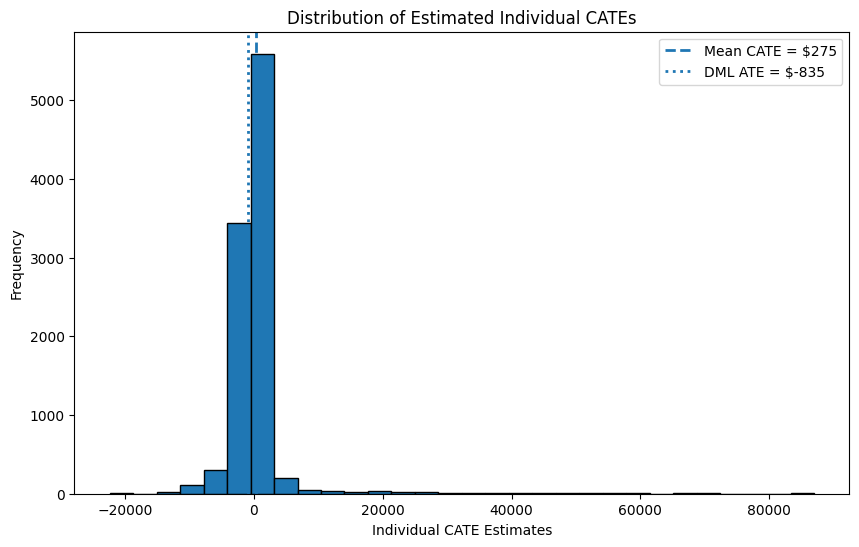

=== High-Response Group Definition ===
75th percentile threshold: $87
High-response group size: 2479
Low-response group size:  7436

Variables available for comparison: ['inc', 'age', 'educ', 'fsize', 'twoearn', 'pira', 'hown']

=== Subgroup Comparison Table ===
         High Response Mean  Low Response Mean  Difference (High - Low)
inc            39773.687500       36342.816406              3430.871094
age               45.185962          39.684777                 5.501185
educ              13.654699          13.056751                 0.597949
fsize              2.552239           2.970414                -0.418175
twoearn            0.317467           0.401963                -0.084497
pira               0.491327           0.159091                 0.332236
hown               0.703106           0.612561                 0.090546

=== Top 15 Variables with Largest Positive Differences ===
         High Response Mean  Low Response Mean  Difference (High - Low)
tw            120751.671875  

In [15]:
# -----------------------------------------------------------
# YOUR TASK — Create CATE histogram and identify high-response subgroup
# -----------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# Step 1: Plot histogram of individual CATE estimates
# Include vertical lines for mean CATE and DML ATE
# -----------------------------------------------------------

mean_cate = np.mean(cate_predictions)
dml_ate = dml_plr.coef[0]

plt.figure(figsize=(10, 6))
plt.hist(cate_predictions, bins=30, edgecolor='black')
plt.axvline(mean_cate, linestyle='--', linewidth=2, label=f'Mean CATE = ${mean_cate:,.0f}')
plt.axvline(dml_ate, linestyle=':', linewidth=2, label=f'DML ATE = ${dml_ate:,.0f}')
plt.xlabel('Individual CATE Estimates')
plt.ylabel('Frequency')
plt.title('Distribution of Estimated Individual CATEs')
plt.legend()
plt.show()

# -----------------------------------------------------------
# Step 2: Identify the "high-response" subgroup
# Define high-response as CATE above the 75th percentile
# -----------------------------------------------------------

threshold = np.percentile(cate_predictions, 75)

# Add CATE predictions to the dataframe
df_analysis = df.copy()
df_analysis['cate_hat'] = cate_predictions
df_analysis['high_response'] = (df_analysis['cate_hat'] >= threshold).astype(int)

high_resp = df_analysis[df_analysis['high_response'] == 1]
low_resp = df_analysis[df_analysis['high_response'] == 0]

print("=== High-Response Group Definition ===")
print(f"75th percentile threshold: ${threshold:,.0f}")
print(f"High-response group size: {len(high_resp)}")
print(f"Low-response group size:  {len(low_resp)}")
print()

# -----------------------------------------------------------
# Compare characteristics
# Pick a few important variables if they exist
# -----------------------------------------------------------

candidate_vars = ['income', 'inc', 'age', 'educ', 'fsize', 'married', 'twoearn', 'pira', 'hown']
compare_vars = [col for col in candidate_vars if col in df_analysis.columns]

print("Variables available for comparison:", compare_vars)
print()

if len(compare_vars) > 0:
    comparison_table = pd.DataFrame({
        'High Response Mean': high_resp[compare_vars].mean(),
        'Low Response Mean': low_resp[compare_vars].mean(),
        'Difference (High - Low)': high_resp[compare_vars].mean() - low_resp[compare_vars].mean()
    })

    print("=== Subgroup Comparison Table ===")
    print(comparison_table)
else:
    print("No candidate comparison variables were found in the dataframe.")
    print("Use print(df.columns) to inspect available variable names.")

# -----------------------------------------------------------
# Optional: Compare all numeric variables
# This is helpful if you are not sure which columns are available
# -----------------------------------------------------------

numeric_cols = df_analysis.select_dtypes(include=[np.number]).columns.tolist()
exclude_cols = [y_col, d_col, 'cate_hat', 'high_response']
numeric_compare_cols = [col for col in numeric_cols if col not in exclude_cols]

all_numeric_comparison = pd.DataFrame({
    'High Response Mean': high_resp[numeric_compare_cols].mean(),
    'Low Response Mean': low_resp[numeric_compare_cols].mean(),
    'Difference (High - Low)': high_resp[numeric_compare_cols].mean() - low_resp[numeric_compare_cols].mean()
}).sort_values(by='Difference (High - Low)', ascending=False)

print()
print("=== Top 15 Variables with Largest Positive Differences ===")
print(all_numeric_comparison.head(15))

print()
print("=== Top 15 Variables with Largest Negative Differences ===")
print(all_numeric_comparison.tail(15))

=== Causal Forest CATE by Income Quartile ===
  inc_quartile        mean           std  count           min           max
0           Q1   60.954088   1246.374066   2481 -10599.845153  21894.070257
1           Q2  191.615334   2468.369952   2477 -10113.591641  44737.392656
2           Q3    4.130358   4105.816797   2478 -14267.448383  67578.722114
3           Q4  842.363499  10571.100002   2479 -22371.206335  86969.545546

=== Heterogeneity Comparison ===
Between-quartile range in mean CATE: $838
Average within-quartile std of CATE: $4,598

Interpretation: Within-quartile variation is larger than the difference in quartile means.
This suggests subgroup DML by income quartile misses substantial heterogeneity within quartiles.

=== Within-Quartile Spread ===
Q1: Mean = $61, Std = $1,246, Min = $-10,600, Max = $21,894
Q2: Mean = $192, Std = $2,468, Min = $-10,114, Max = $44,737
Q3: Mean = $4, Std = $4,106, Min = $-14,267, Max = $67,579
Q4: Mean = $842, Std = $10,571, Min = $-22,371, Max =

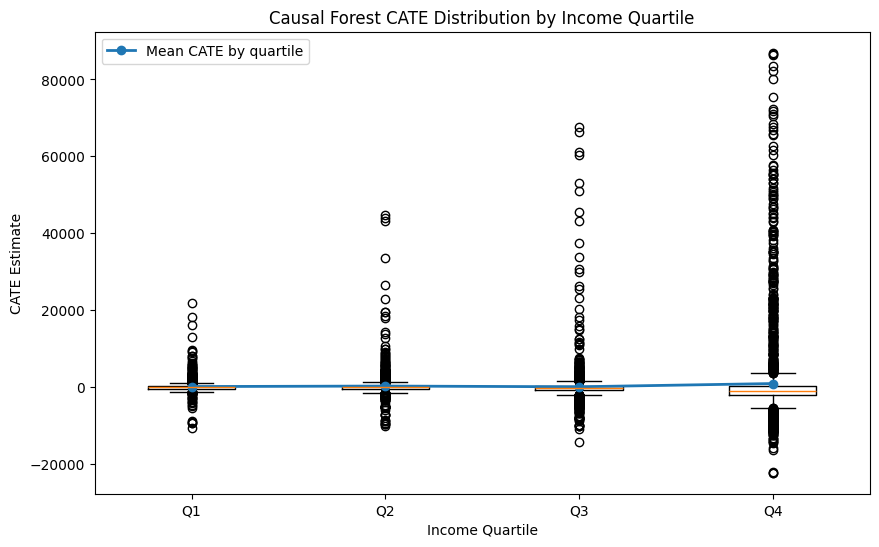

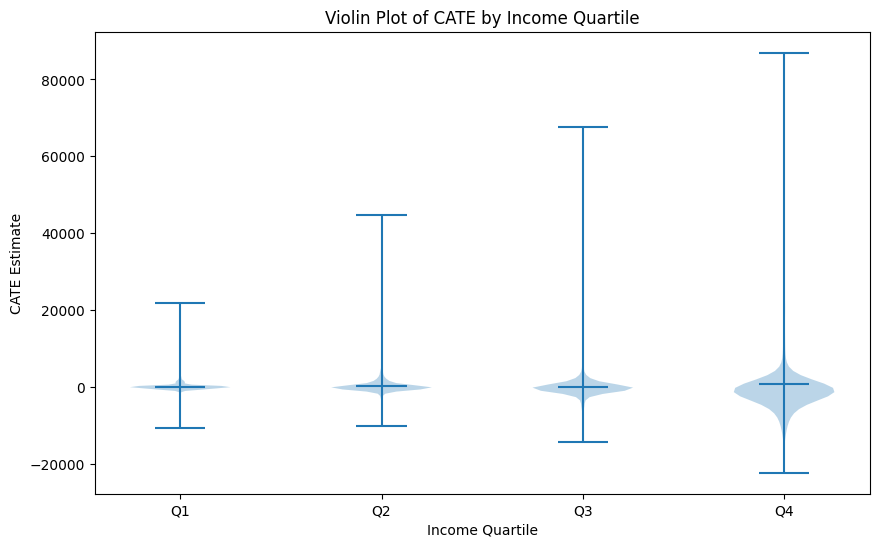


Key question: Does the Causal Forest reveal heterogeneity
WITHIN income quartiles that subgroup DML would miss?


In [16]:
# -----------------------------------------------------------
# EXTEND — Compare subgroup DML to Causal Forest CATE
# -----------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make sure we have a working dataframe called "data"
data = df.copy()

# Add CATE predictions to the data
data['cate_pred'] = cate_predictions

# Step 1: Compute mean Causal Forest CATE by income quartile
data['inc_quartile'] = pd.qcut(data['inc'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

# -----------------------------------------------------------
# Group CATE predictions by income quartile
# For each quartile, compute mean CATE and std CATE
# -----------------------------------------------------------
quartile_summary = (
    data.groupby('inc_quartile', observed=False)['cate_pred']
    .agg(['mean', 'std', 'count', 'min', 'max'])
    .reset_index()
)

print("=== Causal Forest CATE by Income Quartile ===")
print(quartile_summary)
print()

# -----------------------------------------------------------
# Step 2: Within each income quartile, how much variation remains?
# Compare within-quartile std to between-quartile mean differences
# -----------------------------------------------------------
between_range = quartile_summary['mean'].max() - quartile_summary['mean'].min()
avg_within_std = quartile_summary['std'].mean()

print("=== Heterogeneity Comparison ===")
print(f"Between-quartile range in mean CATE: ${between_range:,.0f}")
print(f"Average within-quartile std of CATE: ${avg_within_std:,.0f}")
print()

if avg_within_std > between_range:
    print("Interpretation: Within-quartile variation is larger than the difference in quartile means.")
    print("This suggests subgroup DML by income quartile misses substantial heterogeneity within quartiles.")
else:
    print("Interpretation: Between-quartile differences are at least as large as typical within-quartile variation.")
    print("Income quartiles capture some heterogeneity, though individual-level variation may still remain.")
print()

# Optional: print each quartile's within-bin spread more explicitly
print("=== Within-Quartile Spread ===")
for _, row in quartile_summary.iterrows():
    print(
        f"{row['inc_quartile']}: "
        f"Mean = ${row['mean']:,.0f}, "
        f"Std = ${row['std']:,.0f}, "
        f"Min = ${row['min']:,.0f}, "
        f"Max = ${row['max']:,.0f}"
    )
print()

# -----------------------------------------------------------
# Step 3: Visualize
# Box plot of CATE distribution by income quartile
# Overlay quartile-level mean CATE
# -----------------------------------------------------------
quartile_order = ['Q1', 'Q2', 'Q3', 'Q4']
cate_by_quartile = [
    data.loc[data['inc_quartile'] == q, 'cate_pred'].values
    for q in quartile_order
]

quartile_means = [
    data.loc[data['inc_quartile'] == q, 'cate_pred'].mean()
    for q in quartile_order
]

plt.figure(figsize=(10, 6))
plt.boxplot(cate_by_quartile, tick_labels=quartile_order)
plt.plot(range(1, 5), quartile_means, marker='o', linewidth=2, label='Mean CATE by quartile')
plt.xlabel('Income Quartile')
plt.ylabel('CATE Estimate')
plt.title('Causal Forest CATE Distribution by Income Quartile')
plt.legend()
plt.show()

# -----------------------------------------------------------
# Optional alternative: Violin plot if you want a richer distribution view
# -----------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.violinplot(cate_by_quartile, showmeans=True, showextrema=True)
plt.xticks(range(1, 5), quartile_order)
plt.xlabel('Income Quartile')
plt.ylabel('CATE Estimate')
plt.title('Violin Plot of CATE by Income Quartile')
plt.show()

print('\nKey question: Does the Causal Forest reveal heterogeneity')
print('WITHIN income quartiles that subgroup DML would miss?')

---

## Reflection

Answer in 3-5 sentences:

**When would you choose DML for ATE estimation vs. Causal Forests for CATE estimation?**

Consider:
- What is your research question? (average policy effect vs. targeting)
- How much data do you have? (CATE requires more observations per subgroup)
- How interpretable do the results need to be? (ATE is a single number; CATE is a distribution)
- What are the credibility concerns? (ATE with sensitivity analysis vs. CATE with wider CIs)

I would choose DML when my research question focuses on estimating a single average treatment effect for policy evaluation, where interpretability and statistical credibility are the primary goals. DML is more data-efficient and provides a clear, easily communicable estimate, especially when paired with sensitivity analysis to assess robustness to omitted variable bias. In contrast, I would use Causal Forests when the goal is to understand treatment effect heterogeneity and target interventions to specific subgroups, since it provides individual-level CATE estimates. However, CATE estimation typically requires larger sample sizes and results in more uncertainty, making interpretation more complex. Therefore, DML is preferable for high-level policy impact, while Causal Forests are better suited for personalized or targeted decision-making.

---

## Digital Portfolio: Institutional Signaling

### Generate Your Professional README

Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

```text
"I need help writing a project description for my data science lab.
**Important Rule:** Do NOT generate any Python code for me.

**What I did in this lab:**
* Diagnosed and fixed a broken manual DML implementation (3 bugs:
  data leakage in cross-fitting, missing treatment residualization,
  wrong IV-formula for theta)
* Verified the fix recovers the true ATE (=5.0) on a simulated DGP
* Estimated the ATE of 401(k) eligibility on net financial assets
  using DoubleML with Random Forest nuisance learners and 5-fold cross-fitting
* Ran sensitivity analysis to assess robustness to unmeasured confounders
* Fit a CausalForestDML (EconML) to estimate individual-level CATEs
* Compared subgroup DML (quartile-level) to Causal Forest (individual-level)
  heterogeneity detection
* Key finding: [FILL IN — ATE, robustness, which method reveals finer heterogeneity?]

**Please write a README.md entry including:**
1. Project Title: Causal ML — DML and Causal Forests for Policy Evaluation
2. Objective: A professional one-sentence summary
3. Methodology: Bullet points of technical steps
4. Key Findings: Summary of results
Make this sound like a professional tech economist wrote it."
```

### Push to GitHub

```bash
cd econ-lab-24-causal-ml
git add notebooks/ figures/ README.md
git commit -m "Lab 24: Causal ML — DML & Causal Forests for 401(k) Policy"
git push origin main
```

Submit your GitHub repo link on Canvas.